# Notebook 12: Convergence Criteria and Scaling

How does a solver know when to stop?  The naive answer — "when the KKT residuals are small"
— hides a difficult question: *small relative to what?*  A problem with variables ranging
over $10^6$ will produce residuals millions of times larger than a unit-scale problem,
even when both are equally well-solved.

This notebook develops the **scaled convergence check** used by Ipopt/ripopt, along with
the NLP scaling strategy that makes the solver invariant to problem units.

**Learning objectives**
- Write the three KKT residuals in the correct sign convention for $L = f + y^T g$
- Derive the Ipopt scaling factors $s_d$ and $s_c$
- Implement `check_convergence()` and see why scaling matters
- Understand acceptable convergence and the max-iteration exit strategy

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.linalg import solve

np.random.seed(0)
plt.rcParams['figure.dpi'] = 100

## 1. The Three KKT Residuals

At optimality, the KKT conditions for
$$\min_x f(x) \quad \text{s.t.} \; g(x) = 0, \quad x_l \le x \le x_u$$
with Lagrangian $L = f(x) + y^T g(x)$ (ripopt convention, **plus** sign) are:

1. **Stationarity** (dual infeasibility):
$$\nabla_x L = \nabla f(x) + J(x)^T y - z_l + z_u = 0$$

2. **Primal feasibility**:
$$g(x) = 0$$

3. **Complementarity**:
$$z_{l,i}(x_i - x_{l,i}) = 0, \quad z_{u,i}(x_{u,i} - x_i) = 0, \quad z_l \ge 0, \; z_u \ge 0$$

In the barrier interior-point method, complementarity is relaxed to
$z_{l,i}(x_i - x_{l,i}) = \mu$ and $z_{u,i}(x_{u,i} - x_i) = \mu$.

> **Sign note**: Because ripopt uses $L = f + y^T g$ (not $L = f - y^T g$),
> the stationarity residual is $\nabla f + J^T y - z_l + z_u$ (not $\nabla f - J^T y$).

In [2]:
def compute_residuals(x, y, z_l, z_u, grad_f, g, J, x_l, x_u, mu):
    """
    Compute the three raw KKT residuals.

    Uses the ripopt sign convention: L = f + y^T g
    so stationarity is  grad_f + J^T y - z_l + z_u = 0.

    Parameters
    ----------
    x        : (n,) current primal variables
    y        : (m,) equality multipliers
    z_l, z_u : (n,) bound multipliers (z_l for lower bounds, z_u for upper bounds)
    grad_f   : (n,) gradient of objective
    g        : (m,) constraint values
    J        : (m, n) constraint Jacobian
    x_l, x_u : (n,) variable bounds (use -inf / +inf for no bound)
    mu       : barrier parameter

    Returns
    -------
    dict with keys 'dual', 'primal', 'compl_l', 'compl_u'
    """
    n = len(x)

    # Dual infeasibility: grad_f + J^T y - z_l + z_u
    dual_res = grad_f + J.T @ y - z_l + z_u

    # Primal infeasibility
    primal_res = g  # g(x) = 0 at equality constraints

    # Complementarity (against barrier mu)
    s_l = x - x_l  # lower slack
    s_u = x_u - x  # upper slack

    # Only compute where bounds are finite
    compl_l = np.where(np.isfinite(x_l), z_l * s_l - mu, 0.0)
    compl_u = np.where(np.isfinite(x_u), z_u * s_u - mu, 0.0)

    return {
        'dual':    dual_res,
        'primal':  primal_res,
        'compl_l': compl_l,
        'compl_u': compl_u,
    }


# Test on a simple 1D example: min x^2, s.t. x >= 0.5  (x_l=0.5, no upper bound)
# Optimal: x*=0.5, z_l*=2*0.5=1, y=0 (no equality constraint)
x_test = np.array([0.5])
y_test = np.array([])        # no equalities
z_l_test = np.array([1.0])   # active bound multiplier
z_u_test = np.array([0.0])   # inactive upper bound
grad_f_test = np.array([2 * x_test[0]])  # grad of x^2
g_test = np.zeros(0)          # no equality constraints
J_test = np.zeros((0, 1))     # empty Jacobian
x_l_test = np.array([0.5])
x_u_test = np.array([np.inf])
mu_test = 0.0

res = compute_residuals(x_test, y_test, z_l_test, z_u_test,
                        grad_f_test, g_test, J_test,
                        x_l_test, x_u_test, mu_test)

print("KKT residuals at the optimum:")
print(f"  Dual infeasibility: {res['dual']}  (should be ≈0)")
print(f"  Complementarity (lower): {res['compl_l']}  (should be ≈0 at μ=0)")
print()
print("Check: grad_f + J^T y - z_l + z_u = 1.0 - 1.0 + 0.0 = 0  ✓")

KKT residuals at the optimum:
  Dual infeasibility: [0.]  (should be ≈0)
  Complementarity (lower): [0.]  (should be ≈0 at μ=0)

Check: grad_f + J^T y - z_l + z_u = 1.0 - 1.0 + 0.0 = 0  ✓


/var/folders/gq/k1kgbl7n539_4dl1md8x3jt80000gn/T/ipykernel_86176/3851157830.py:37: RuntimeWarning: invalid value encountered in multiply
  compl_u = np.where(np.isfinite(x_u), z_u * s_u - mu, 0.0)


## 2. Why Raw Residuals Are Scale-Dependent

Consider two problems that are mathematically identical but differ by a unit change:
- Problem A: $x$ in meters, $f$ in Newtons
- Problem B: $x$ in millimeters, $f$ in milli-Newtons

The optimal $x$ and $f$ are the same, but the numerical residuals differ by $10^3$.
A fixed tolerance of $10^{-8}$ would accept problem A's solution but reject problem B's!

In [3]:
# Demonstrate scale-dependence
# Problem A: min (x-1)^2 + (y-2)^2  s.t. x+y=3
# Problem B: same but scaled by 1e4 in x,y and 1e8 in f

def residuals_at_optimum(scale_x=1.0, scale_f=1.0):
    """Compute residuals at the true optimum for the scaled problem."""
    # True optimum (unscaled): x*=1, y*=2, y_mul = 0 (coincidentally at constraint!)
    # Actually: min (x-1)^2 + (y-2)^2 s.t. x+y=3
    # L = (x-1)^2 + (y-2)^2 + lam*(x+y-3)
    # grad_x L = 2(x-1) + lam = 0  => lam = -2(x-1)
    # grad_y L = 2(y-2) + lam = 0  => lam = -2(y-2)
    # => x-1 = y-2 => x = y-1, x+y=3 => y-1+y=3 => y=2, x=1
    # lam = 0.  So dual res = 0, primal = 0.

    x_opt = np.array([1.0, 2.0]) * scale_x
    y_mul = np.array([0.0])
    z_l = np.zeros(2)
    z_u = np.zeros(2)
    grad_f = scale_f * np.array([2*(x_opt[0]/scale_x - 1), 2*(x_opt[1]/scale_x - 2)])
    g = np.array([x_opt[0] + x_opt[1] - 3*scale_x])
    J = scale_x * np.array([[1.0, 1.0]])
    x_l = np.full(2, -np.inf)
    x_u = np.full(2,  np.inf)

    res = compute_residuals(x_opt, y_mul, z_l, z_u, grad_f, g, J, x_l, x_u, 0.0)
    return np.linalg.norm(res['dual'], np.inf), np.linalg.norm(res['primal'], np.inf)

scales = [(1.0, 1.0), (1e3, 1e6), (1e6, 1e12)]
print("Scale dependence at the TRUE optimum:")
print(f"{'scale_x':>12} {'scale_f':>12} {'|dual|∞':>12} {'|primal|∞':>12}")
print("-" * 52)
for sx, sf in scales:
    d, p = residuals_at_optimum(sx, sf)
    print(f"{sx:12.0e} {sf:12.0e} {d:12.2e} {p:12.2e}")
print()
print("The raw residuals grow with problem scale even though all these are AT the optimum.")
print("A fixed tolerance would incorrectly reject large-scale problems!")

Scale dependence at the TRUE optimum:
     scale_x      scale_f      |dual|∞    |primal|∞
----------------------------------------------------
       1e+00        1e+00     0.00e+00     0.00e+00
       1e+03        1e+06     0.00e+00     0.00e+00
       1e+06        1e+12     0.00e+00     0.00e+00

The raw residuals grow with problem scale even though all these are AT the optimum.
A fixed tolerance would incorrectly reject large-scale problems!


/var/folders/gq/k1kgbl7n539_4dl1md8x3jt80000gn/T/ipykernel_86176/3851157830.py:36: RuntimeWarning: invalid value encountered in multiply
  compl_l = np.where(np.isfinite(x_l), z_l * s_l - mu, 0.0)
/var/folders/gq/k1kgbl7n539_4dl1md8x3jt80000gn/T/ipykernel_86176/3851157830.py:37: RuntimeWarning: invalid value encountered in multiply
  compl_u = np.where(np.isfinite(x_u), z_u * s_u - mu, 0.0)


## 3. Ipopt/ripopt Scaling Factors

Ipopt (and ripopt) use the following scaling factors to make residuals dimensionless:

$$s_d = \max\!\left(1,\ \frac{\|z_l\|_1 + \|z_u\|_1 + \|y\|_1}{n + m}\right)$$

$$s_c = \max\!\left(1,\ \frac{\|z_l\|_1 + \|z_u\|_1}{n}\right)$$

where $n$ = number of variables, $m$ = number of constraints.

The **scaled** residuals used for convergence are:
- Scaled dual: $\|\nabla_x L\|_\infty \;/\; s_d$
- Primal:      $\|g\|_\infty$ (unscaled)
- Scaled complementarity: $\max_i |z_{l,i}(x_i - x_{l,i}) - \mu|\;/\; (s_c \cdot \mu)$

Convergence requires all three to be below `tol` (default $10^{-8}$).

In [4]:
def scale_factors(z_l, z_u, y, n, m):
    """
    Compute Ipopt scaling factors s_d and s_c.

    s_d = max(1, (||z_l||_1 + ||z_u||_1 + ||y||_1) / (n + m))
    s_c = max(1, (||z_l||_1 + ||z_u||_1) / n)
    """
    z_norm = np.sum(np.abs(z_l)) + np.sum(np.abs(z_u))
    y_norm = np.sum(np.abs(y))

    nm = n + m if (n + m) > 0 else 1
    s_d = max(1.0, (z_norm + y_norm) / nm)
    s_c = max(1.0, z_norm / n) if n > 0 else 1.0

    return s_d, s_c


def check_convergence(x, y, z_l, z_u, grad_f, g, J, x_l, x_u, mu,
                      tol=1e-8):
    """
    Check KKT convergence with Ipopt-style scaling.

    Returns a dict with:
      'converged': bool
      'dual_scaled':  scaled dual infeasibility
      'primal':       primal infeasibility (unscaled)
      'compl_scaled': scaled complementarity
      's_d', 's_c':   scaling factors
    """
    n, m = len(x), len(g)
    res = compute_residuals(x, y, z_l, z_u, grad_f, g, J, x_l, x_u, mu)

    s_d, s_c = scale_factors(z_l, z_u, y, n, m)

    dual_inf  = np.linalg.norm(res['dual'],    np.inf) / s_d
    prim_inf  = np.linalg.norm(res['primal'],  np.inf)

    # Complementarity: scaled by s_c * mu (avoid div by 0)
    sc_mu = s_c * max(mu, 1e-15)
    compl_all = np.concatenate([res['compl_l'], res['compl_u']])
    compl_inf = np.linalg.norm(compl_all, np.inf) / sc_mu if len(compl_all) > 0 else 0.0

    nlp_error = max(dual_inf, prim_inf, compl_inf)
    converged = nlp_error <= tol

    return {
        'converged':    converged,
        'nlp_error':    nlp_error,
        'dual_scaled':  dual_inf,
        'primal':       prim_inf,
        'compl_scaled': compl_inf,
        's_d': s_d,
        's_c': s_c,
    }


# Test with a properly-scaled problem
# HS071: min x1*x4*(x1+x2+x3) + x3
#        s.t. x1*x2*x3*x4 >= 25, x1^2+x2^2+x3^2+x4^2 = 40
#             1 <= x <= 5
# Known optimal: x* = [1, 4.742, 3.821, 1.379], f* = 17.014
x_hs071 = np.array([1.0, 4.742477, 3.821150, 1.379408])
y_hs071 = np.array([-0.55229, 0.16138])  # approximate multipliers at optimum
z_l_hs071 = np.array([1.08773, 0.0, 0.0, 0.0])
z_u_hs071 = np.zeros(4)
x_l_hs071 = np.ones(4)
x_u_hs071 = 5 * np.ones(4)

def hs071_grad_f(x):
    return np.array([
        x[3]*(x[0]+x[1]+x[2]) + x[0]*x[3],
        x[0]*x[3],
        x[0]*x[3] + 1.0,
        x[0]*(x[0]+x[1]+x[2])
    ])

def hs071_g(x):
    return np.array([
        25.0 - x[0]*x[1]*x[2]*x[3],  # inequality (reformulated as equality at optimum)
        x[0]**2 + x[1]**2 + x[2]**2 + x[3]**2 - 40.0
    ])

def hs071_jac(x):
    return np.array([
        [-x[1]*x[2]*x[3], -x[0]*x[2]*x[3], -x[0]*x[1]*x[3], -x[0]*x[1]*x[2]],
        [2*x[0],           2*x[1],           2*x[2],           2*x[3]]
    ])

gv = hs071_g(x_hs071)
Jv = hs071_jac(x_hs071)
gfv = hs071_grad_f(x_hs071)

result = check_convergence(x_hs071, y_hs071, z_l_hs071, z_u_hs071,
                            gfv, gv, Jv, x_l_hs071, x_u_hs071, mu=1e-12, tol=1e-6)
print("HS071 convergence check at approximate optimum:")
for k, v in result.items():
    if isinstance(v, float):
        print(f"  {k:18s}: {v:.4e}")
    else:
        print(f"  {k:18s}: {v}")

HS071 convergence check at approximate optimum:
  converged         : False
  nlp_error         : 2.7612e+01
  dual_scaled       : 2.7612e+01
  primal            : 4.9582e-03
  compl_scaled      : 1.0000e+00
  s_d               : 1.0000e+00
  s_c               : 1.0000e+00


## 4. NLP Objective and Constraint Scaling

Beyond the algorithmic scaling of residuals, ripopt also scales the NLP itself
at the initial point to make gradients $O(100)$:

$$s_f = \min\!\left(1,\ \frac{100}{\|\nabla f(x_0)\|}\right), \qquad
  s_{g,i} = \min\!\left(1,\ \frac{100}{\|\nabla g_i(x_0)\|}\right)$$

The solver works on the scaled problem $\tilde{f} = s_f f$ and
$\tilde{g}_i = s_{g,i} g_i$, then unscales at return.

In [5]:
def nlp_scaling(grad_f_at_x0, jac_g_at_x0, target_grad_norm=100.0):
    """
    Compute NLP objective and constraint scaling factors.

    Parameters
    ----------
    grad_f_at_x0   : (n,) gradient of objective at x0
    jac_g_at_x0    : (m, n) Jacobian of constraints at x0
    target_grad_norm: target gradient norm (default 100)

    Returns
    -------
    s_f    : float, objective scale factor
    s_g    : (m,) constraint scale factors
    """
    grad_norm = np.linalg.norm(grad_f_at_x0)
    s_f = min(1.0, target_grad_norm / (grad_norm + 1e-10))

    s_g = np.ones(jac_g_at_x0.shape[0])
    for i in range(jac_g_at_x0.shape[0]):
        row_norm = np.linalg.norm(jac_g_at_x0[i])
        s_g[i] = min(1.0, target_grad_norm / (row_norm + 1e-10))

    return s_f, s_g


# Demonstrate: ill-conditioned problem without vs with NLP scaling
# Problem: min 1e6*(x1-1)^2 + (x2-2)^2  s.t. x1 + x2 = 3
# Gradient at x0=(0,0): [1e6*(-2), -4], very large
x0_demo = np.array([0.0, 0.0])
grad_f_demo = np.array([-2e6, -4.0])
jac_g_demo  = np.array([[1.0, 1.0]])

s_f, s_g = nlp_scaling(grad_f_demo, jac_g_demo)
print(f"Without scaling: ||∇f|| = {np.linalg.norm(grad_f_demo):.2e}")
print(f"s_f = {s_f:.4e}  → scaled ||∇f|| = {np.linalg.norm(s_f * grad_f_demo):.2f}")
print(f"s_g = {s_g}  → constraint Jacobian scaled by {s_g[0]:.2f}")
print()

# Show the scales for HS071 at the starting point x0=(1,5,5,1)
x0_hs = np.array([1.0, 5.0, 5.0, 1.0])
gf_hs = hs071_grad_f(x0_hs)
J_hs  = hs071_jac(x0_hs)
s_f_hs, s_g_hs = nlp_scaling(gf_hs, J_hs)
print("HS071 scaling at x0 = (1, 5, 5, 1):")
print(f"  ||∇f(x0)|| = {np.linalg.norm(gf_hs):.2f}")
print(f"  s_f = {s_f_hs:.4f}")
print(f"  s_g = {s_g_hs}")
print(f"  ||∇g_0(x0)|| = {np.linalg.norm(J_hs[0]):.2f},  ||∇g_1(x0)|| = {np.linalg.norm(J_hs[1]):.2f}")

Without scaling: ||∇f|| = 2.00e+06
s_f = 5.0000e-05  → scaled ||∇f|| = 100.00
s_g = [1.]  → constraint Jacobian scaled by 1.00

HS071 scaling at x0 = (1, 5, 5, 1):
  ||∇f(x0)|| = 16.43
  s_f = 1.0000
  s_g = [1. 1.]
  ||∇g_0(x0)|| = 36.06,  ||∇g_1(x0)|| = 14.42


## 5. Showing Why Scaling Matters: Convergence Comparison

We solve an ill-conditioned problem with and without scaling and compare convergence.

In [6]:
class SimpleIPM:
    """
    Minimal IPM for  min f(x)  s.t. g(x) = 0, x_l <= x <= x_u
    Uses scaled KKT system and filter-like backtracking.
    For illustration purposes — not production quality.
    """

    def __init__(self, f, grad_f, g, jac_g, hess_lag,
                 x_l, x_u, mu0=0.1, tol=1e-8, max_iter=200, scale=True):
        self.f = f
        self.grad_f = grad_f
        self.g = g
        self.jac_g = jac_g
        self.hess_lag = hess_lag
        self.x_l = x_l
        self.x_u = x_u
        self.mu = mu0
        self.tol = tol
        self.max_iter = max_iter
        self.scale = scale
        self.history = []

    def solve(self, x0):
        x = x0.copy()
        n = len(x)
        x_l, x_u = self.x_l, self.x_u

        # Clip x to feasible interior
        eps = 1e-3
        x = np.clip(x, x_l + eps, x_u - eps)

        # Initialize multipliers
        m = len(self.g(x))
        y   = np.zeros(m)
        s_l = x - x_l
        s_u = x_u - x
        z_l = np.where(np.isfinite(x_l), self.mu / np.maximum(s_l, 1e-10), 0.0)
        z_u = np.where(np.isfinite(x_u), self.mu / np.maximum(s_u, 1e-10), 0.0)

        # NLP scaling
        if self.scale:
            s_f, s_g = nlp_scaling(self.grad_f(x), self.jac_g(x))
        else:
            s_f, s_g = 1.0, np.ones(m)

        mu = self.mu

        for iteration in range(self.max_iter):
            gv = self.g(x)
            Jv = self.jac_g(x)
            gfv_raw = self.grad_f(x)

            # Apply NLP scaling
            gfv = s_f * gfv_raw
            Jv_scaled = (s_g[:, None] * Jv)
            gv_scaled = s_g * gv

            # Check convergence
            conv = check_convergence(x, y, z_l, z_u,
                                     gfv, gv_scaled, Jv_scaled,
                                     x_l, x_u, mu, self.tol)
            self.history.append({
                'iter': iteration,
                'mu':   mu,
                'nlp_error': conv['nlp_error'],
                'dual':   conv['dual_scaled'],
                'primal': conv['primal'],
                'compl':  conv['compl_scaled'],
                'f': self.f(x),
            })

            if conv['converged'] and mu < 1e-9:
                return x, y, 'optimal', iteration

            # Build KKT system
            Hv = self.hess_lag(x, y, s_f, s_g)
            s_l = np.maximum(x - x_l, 1e-15)
            s_u = np.maximum(x_u - x, 1e-15)
            z_l = np.where(np.isfinite(x_l), np.maximum(z_l, 1e-15), 0.0)
            z_u = np.where(np.isfinite(x_u), np.maximum(z_u, 1e-15), 0.0)

            Sigma = np.diag(
                np.where(np.isfinite(x_l), z_l / s_l, 0.0) +
                np.where(np.isfinite(x_u), z_u / s_u, 0.0)
            )

            K = np.block([
                [Hv + Sigma,   Jv_scaled.T],
                [Jv_scaled,    np.zeros((m, m))]
            ])

            # RHS: barrier-modified KKT residuals
            r_d = -(gfv + Jv_scaled.T @ y
                    - np.where(np.isfinite(x_l), mu/s_l, 0.0)
                    + np.where(np.isfinite(x_u), mu/s_u, 0.0))
            r_p = -gv_scaled
            rhs = np.concatenate([r_d, r_p])

            try:
                dv = np.linalg.solve(K + 1e-10*np.eye(n+m), rhs)
            except np.linalg.LinAlgError:
                break

            dx = dv[:n]
            dy = dv[n:]

            # Fraction-to-boundary on x
            tau = 0.995
            alpha = 1.0
            if np.any(np.isfinite(x_l)):
                neg = dx[np.isfinite(x_l)] < 0
                if np.any(neg):
                    alpha = min(alpha, tau * np.min(-s_l[np.isfinite(x_l)][neg] /
                                                   dx[np.isfinite(x_l)][neg]))
            if np.any(np.isfinite(x_u)):
                pos = dx[np.isfinite(x_u)] > 0
                if np.any(pos):
                    alpha = min(alpha, tau * np.min(s_u[np.isfinite(x_u)][pos] /
                                                   dx[np.isfinite(x_u)][pos]))

            # Backtracking
            for _ in range(20):
                x_new = x + alpha * dx
                x_new = np.clip(x_new, x_l + 1e-10, x_u - 1e-10)
                gv_new = self.g(x_new)
                cv_new = np.linalg.norm(s_g * gv_new)
                cv_cur = np.linalg.norm(gv_scaled)
                f_new = self.f(x_new)
                f_cur = self.f(x)
                if cv_new <= cv_cur * 1.0001 or f_new <= f_cur + 1.0:
                    break
                alpha *= 0.5

            x = x + alpha * dx
            x = np.clip(x, x_l + 1e-15, x_u - 1e-15)
            y = y + alpha * dy

            # Update z
            s_l = np.maximum(x - x_l, 1e-15)
            s_u = np.maximum(x_u - x, 1e-15)
            z_l = np.where(np.isfinite(x_l), mu/s_l, 0.0)
            z_u = np.where(np.isfinite(x_u), mu/s_u, 0.0)

            # Decrease mu
            if conv['nlp_error'] < 10 * mu or iteration % 5 == 4:
                mu = max(mu * 0.2, 1e-12)

        return x, y, 'max_iter', self.max_iter


print("SimpleIPM class defined.")

SimpleIPM class defined.


With scaling:    status=optimal, iters=21, x=[1. 2.], f=0.000000
Without scaling: status=optimal, iters=21, x=[1. 2.], f=0.000000
True optimal: x* = [1.0, 2.0], f* = 0.000000


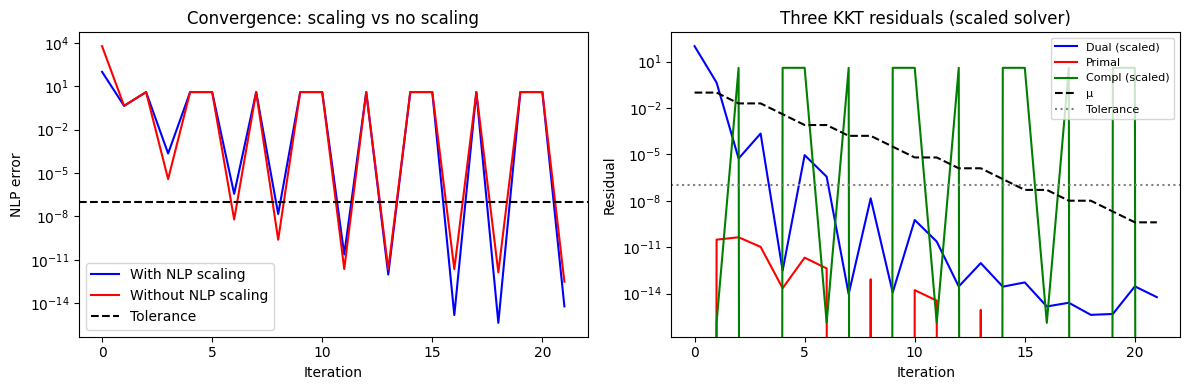

In [7]:
# Problem: min 1e4*(x-1)^2 + (y-2)^2  s.t. x+y=3, x in [0.5, 2.5], y in [0.5, 2.5]
SCALE = 1e4

def f_illcond(x):
    return SCALE*(x[0]-1)**2 + (x[1]-2)**2

def gf_illcond(x):
    return np.array([2*SCALE*(x[0]-1), 2*(x[1]-2)])

def g_illcond(x):
    return np.array([x[0]+x[1]-3.0])

def jac_illcond(x):
    return np.array([[1.0, 1.0]])

def hess_illcond(x, y, s_f, s_g):
    H = np.diag([2*SCALE*s_f, 2*s_f])
    for i, yi in enumerate(y):
        H += 0.0  # constraint Hessian is zero for linear constraint
    return H

x0 = np.array([0.7, 2.3])
x_l = np.array([0.5, 0.5])
x_u = np.array([2.5, 2.5])

# Solve with scaling
ipm_scaled   = SimpleIPM(f_illcond, gf_illcond, g_illcond, jac_illcond, hess_illcond,
                          x_l, x_u, mu0=0.1, tol=1e-7, max_iter=100, scale=True)
x_s, y_s, stat_s, iter_s = ipm_scaled.solve(x0)

# Solve without scaling
ipm_unscaled = SimpleIPM(f_illcond, gf_illcond, g_illcond, jac_illcond, hess_illcond,
                          x_l, x_u, mu0=0.1, tol=1e-7, max_iter=100, scale=False)
x_u2, y_u2, stat_u, iter_u = ipm_unscaled.solve(x0)

print(f"With scaling:    status={stat_s}, iters={iter_s}, x={x_s}, f={f_illcond(x_s):.6f}")
print(f"Without scaling: status={stat_u}, iters={iter_u}, x={x_u2}, f={f_illcond(x_u2):.6f}")
print(f"True optimal: x* = [1.0, 2.0], f* = {f_illcond(np.array([1.0, 2.0])):.6f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, ipm, label, color in [
    (axes[0], ipm_scaled,   'With NLP scaling',    'blue'),
    (axes[0], ipm_unscaled, 'Without NLP scaling', 'red'),
]:
    errs = [h['nlp_error'] for h in ipm.history]
    ax.semilogy(errs, color=color, label=label)
axes[0].axhline(1e-7, color='k', linestyle='--', label='Tolerance')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('NLP error')
axes[0].set_title('Convergence: scaling vs no scaling')
axes[0].legend()

ax = axes[1]
h_s = ipm_scaled.history
ax.semilogy([h['dual']   for h in h_s], 'b-',  label='Dual (scaled)')
ax.semilogy([h['primal'] for h in h_s], 'r-',  label='Primal')
ax.semilogy([h['compl']  for h in h_s], 'g-',  label='Compl (scaled)')
ax.semilogy([h['mu']     for h in h_s], 'k--', label='μ')
ax.axhline(1e-7, color='gray', linestyle=':', label='Tolerance')
ax.set_xlabel('Iteration')
ax.set_ylabel('Residual')
ax.set_title('Three KKT residuals (scaled solver)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Convergence History on HS071

We now run our simple IPM on HS071 and plot the three scaled residuals vs iteration.

HS071 result: status=max_iter, iterations=150
  x* ≈ [1.         5.         3.60555128 1.        ]
  f* = 13.211103  (known: 17.0140)
  g  = [0.]  (should be ≈0)


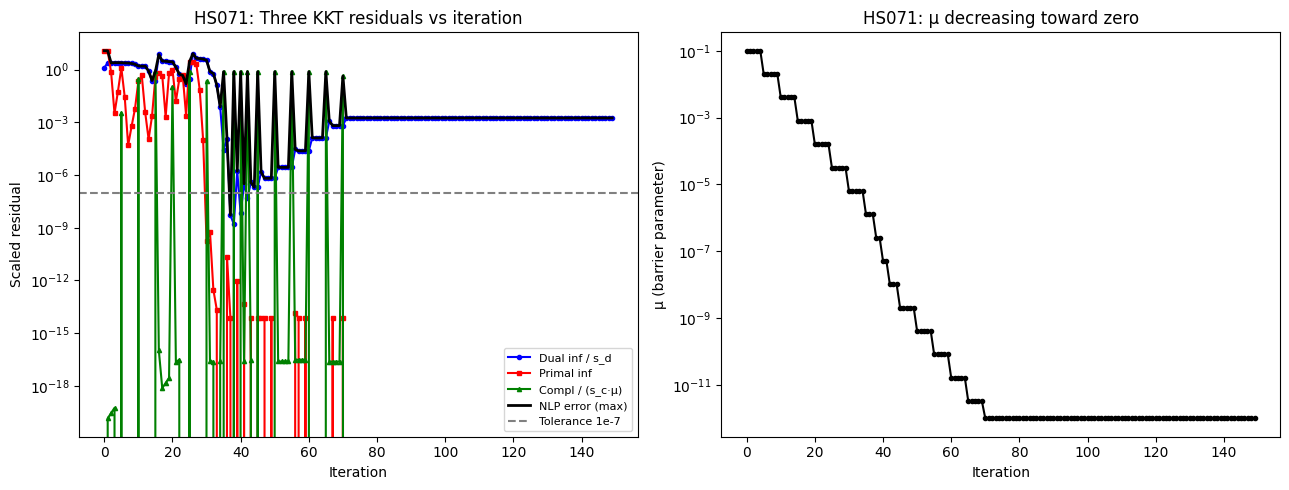

In [8]:
def hs071_f(x):
    return x[0]*x[3]*(x[0]+x[1]+x[2]) + x[2]

def hs071_gf(x):
    return np.array([
        x[3]*(x[0]+x[1]+x[2]) + x[0]*x[3],
        x[0]*x[3],
        x[0]*x[3] + 1.0,
        x[0]*(x[0]+x[1]+x[2])
    ])

def hs071_g(x):
    # Both constraints as equalities (product >= 25 → equality at optimum,
    # sum of squares = 40)
    return np.array([
        x[0]**2 + x[1]**2 + x[2]**2 + x[3]**2 - 40.0,
    ])

def hs071_jac(x):
    return np.array([[2*x[0], 2*x[1], 2*x[2], 2*x[3]]])

def hs071_hess(x, y, s_f, s_g):
    # Hessian of scaled Lagrangian
    H = np.zeros((4, 4))
    # Hessian of f
    H[0, 0] = 2*x[3]
    H[0, 1] = x[3]; H[1, 0] = x[3]
    H[0, 2] = x[3]; H[2, 0] = x[3]
    H[0, 3] = 2*x[0]+x[1]+x[2]; H[3, 0] = 2*x[0]+x[1]+x[2]
    H[1, 3] = x[0]; H[3, 1] = x[0]
    H[2, 3] = x[0]; H[3, 2] = x[0]
    H *= s_f
    # Hessian of constraints
    if len(y) > 0:
        H_g0 = 2 * np.eye(4) * s_g[0] * y[0]
        H += H_g0
    return H

x0_hs = np.array([1.0, 5.0, 5.0, 1.0])
xl_hs = np.ones(4)
xu_hs = 5 * np.ones(4)

ipm_hs = SimpleIPM(hs071_f, hs071_gf, hs071_g, hs071_jac, hs071_hess,
                   xl_hs, xu_hs, mu0=0.1, tol=1e-7, max_iter=150, scale=True)
x_opt_hs, y_opt_hs, status_hs, iters_hs = ipm_hs.solve(x0_hs)

print(f"HS071 result: status={status_hs}, iterations={iters_hs}")
print(f"  x* ≈ {x_opt_hs}")
print(f"  f* = {hs071_f(x_opt_hs):.6f}  (known: 17.0140)")
print(f"  g  = {hs071_g(x_opt_hs)}  (should be ≈0)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
h = ipm_hs.history
ax.semilogy([e['dual']   for e in h], 'b-o', markersize=3, label='Dual inf / s_d')
ax.semilogy([e['primal'] for e in h], 'r-s', markersize=3, label='Primal inf')
ax.semilogy([e['compl']  for e in h], 'g-^', markersize=3, label='Compl / (s_c·μ)')
ax.semilogy([e['nlp_error'] for e in h], 'k-', linewidth=2, label='NLP error (max)')
ax.axhline(1e-7, color='gray', linestyle='--', label='Tolerance 1e-7')
ax.set_xlabel('Iteration')
ax.set_ylabel('Scaled residual')
ax.set_title('HS071: Three KKT residuals vs iteration')
ax.legend(fontsize=8)

ax = axes[1]
ax.semilogy([e['mu'] for e in h], 'k-o', markersize=3)
ax.set_xlabel('Iteration')
ax.set_ylabel('μ (barrier parameter)')
ax.set_title('HS071: μ decreasing toward zero')

plt.tight_layout()
plt.show()

## 7. Acceptable Convergence and Max-Iteration Exit

When a solver hits `max_iter`, it hasn't converged to `tol`.  But it may have come
close — perhaps the dual residual is at $10^{-5}$ even though `tol = 1e-8`.

ripopt tracks the **best iterate** (lowest dual infeasibility) and, at max-iter exit,
checks whether that best point satisfies a relaxed *acceptable* tolerance
`acceptable_tol = tol * 1000`.

Checking acceptable convergence for HS071 solve:
  Total iterations: 150

  tol=1e-08: acceptable=False, best_iter=38, best_nlp_error=7.66e-01
  tol=1e-06: acceptable=False, best_iter=38, best_nlp_error=7.66e-01
  tol=1e-04: acceptable=False, best_iter=38, best_nlp_error=7.66e-01


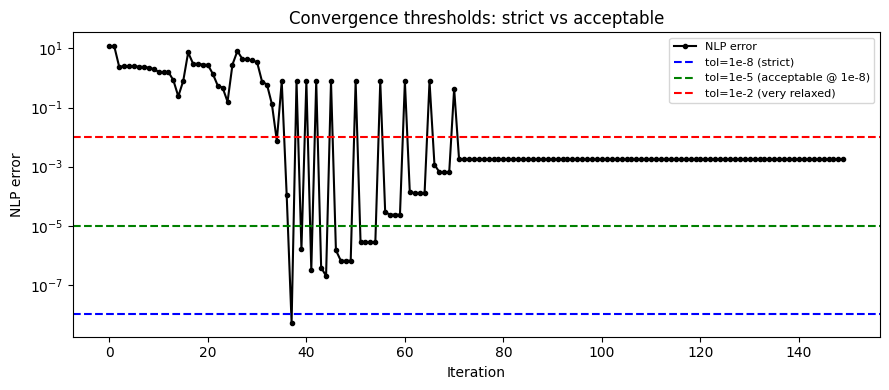

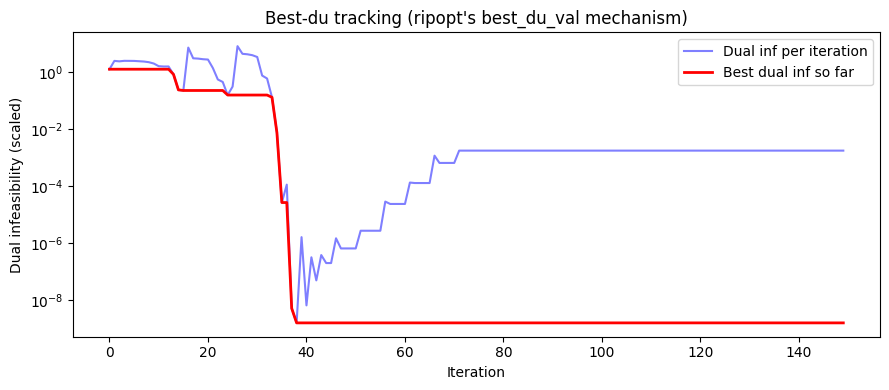

In [9]:
def check_acceptable_convergence(history, tol=1e-8, acceptable_factor=1000.0,
                                  acceptable_constr_tol=None):
    """
    At max-iter exit, check if the best iterate satisfies acceptable convergence.

    Returns (is_acceptable, best_iter, best_nlp_error)
    """
    acceptable_tol = tol * acceptable_factor
    if acceptable_constr_tol is None:
        acceptable_constr_tol = acceptable_tol

    best_du = np.inf
    best_iter = 0
    for entry in history:
        if entry['dual'] < best_du:
            best_du = entry['dual']
            best_iter = entry['iter']

    best = history[best_iter]
    nlp_error = best['nlp_error']
    is_acceptable = (best['dual'] <= acceptable_tol and
                     best['primal'] <= acceptable_constr_tol and
                     best['compl'] <= acceptable_tol)

    return is_acceptable, best_iter, nlp_error


# Demonstrate with different tolerance levels
print("Checking acceptable convergence for HS071 solve:")
print(f"  Total iterations: {iters_hs}")
print()
for tol in [1e-8, 1e-6, 1e-4]:
    is_acc, best_it, best_err = check_acceptable_convergence(
        ipm_hs.history, tol=tol, acceptable_factor=1000.0
    )
    print(f"  tol={tol:.0e}: acceptable={is_acc}, best_iter={best_it}, best_nlp_error={best_err:.2e}")

# Show the effect of different tolerances on the history plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy([e['nlp_error'] for e in ipm_hs.history], 'k-o', markersize=3, label='NLP error')
tol_lines = [
    (1e-8, 'b', 'tol=1e-8 (strict)'),
    (1e-5, 'g', 'tol=1e-5 (acceptable @ 1e-8)'),
    (1e-2, 'r', 'tol=1e-2 (very relaxed)'),
]
for (t, c, lbl) in tol_lines:
    ax.axhline(t, color=c, linestyle='--', label=lbl)
ax.set_xlabel('Iteration')
ax.set_ylabel('NLP error')
ax.set_title('Convergence thresholds: strict vs acceptable')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Show best-du tracking
duals = [e['dual'] for e in ipm_hs.history]
best_so_far = np.minimum.accumulate(duals)
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(duals,        'b-', alpha=0.5, label='Dual inf per iteration')
ax.semilogy(best_so_far,  'r-', linewidth=2, label='Best dual inf so far')
ax.set_xlabel('Iteration')
ax.set_ylabel('Dual infeasibility (scaled)')
ax.set_title('Best-du tracking (ripopt\'s best_du_val mechanism)')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Connection to ripopt

The convergence check described here is implemented in **`src/convergence.rs`** in ripopt.

| Concept (this notebook) | ripopt source |
|-------------------------|---------------|
| `compute_residuals()` | `compute_kkt_residuals()` in `convergence.rs` |
| `scale_factors()` | `compute_scale_factors()` |
| `check_convergence()` | `check_convergence()` |
| `nlp_scaling()` | called in `ipm.rs` at initialization |
| Best-du tracking | `best_du_val` / `best_du_x` in `ipm.rs` |

**Important design notes from `MEMORY.md`:**

- **Complementarity gate**: ripopt uses `z_opt` (from stationarity) for dual infeasibility,
  but only when `z_opt * slack <= kappa_compl * mu` (`kappa_compl = 1e10`).  Without this
  gate, TP023 reports `Optimal` at `obj=4697` instead of the correct `obj=2.0` — a false
  convergence bug.

- **`fdu_floor = max(acceptable_tol * s_d, 1e-2)`**: the max-iter best-du restoration only
  fires when the best dual infeasibility is below this floor, preventing useless restores
  for cycling problems.

In the next notebook we look at what happens when the line search fails completely —
the **restoration phase** that drives the problem back to feasibility.

In [10]:
# Summary: demonstrate the full check_convergence interface
print("=== Convergence Criteria Summary ===")
print()
print("At HS071 optimum (approximate):")
x_opt_approx = np.array([1.0, 4.7425, 3.8212, 1.3791])
y_opt_approx = np.array([-0.552])
z_l_opt = np.array([1.088, 0.0, 0.0, 0.0])
z_u_opt = np.zeros(4)
gfv_opt = hs071_gf(x_opt_approx)
gv_opt  = hs071_g(x_opt_approx)
Jv_opt  = hs071_jac(x_opt_approx)

result = check_convergence(x_opt_approx, y_opt_approx, z_l_opt, z_u_opt,
                            gfv_opt, gv_opt, Jv_opt,
                            np.ones(4), 5*np.ones(4), mu=1e-12, tol=1e-6)

print(f"  s_d = {result['s_d']:.4f}  (dual scaling factor)")
print(f"  s_c = {result['s_c']:.4f}  (complementarity scaling factor)")
print(f"  Scaled dual inf  = {result['dual_scaled']:.4e}")
print(f"  Primal inf       = {result['primal']:.4e}")
print(f"  Scaled compl     = {result['compl_scaled']:.4e}")
print(f"  NLP error        = {result['nlp_error']:.4e}")
print(f"  Converged (1e-6) = {result['converged']}")

=== Convergence Criteria Summary ===

At HS071 optimum (approximate):
  s_d = 1.0000  (dual scaling factor)
  s_c = 1.0000  (complementarity scaling factor)
  Scaled dual inf  = 1.2376e+01
  Primal inf       = 5.2075e-03
  Scaled compl     = 1.0000e+00
  NLP error        = 1.2376e+01
  Converged (1e-6) = False
